In [191]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

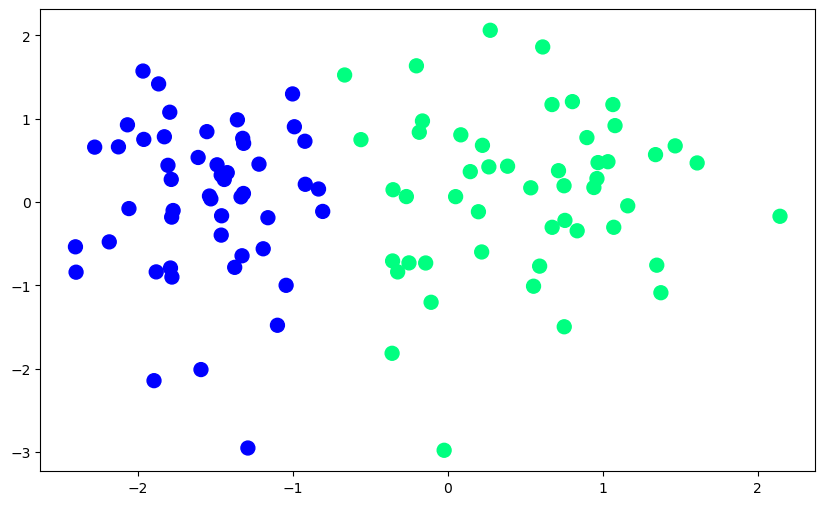

In [192]:

plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [193]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,X.shape[0])
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights

In [194]:
np.random.seed(42)
# def perceptron(X,y):
    
#     X = np.insert(X,0,1,axis=1)
#     weights = np.ones(X.shape[1])
#     lr = 0.1
    
#     for i in range(1000):
#         j = np.random.randint(0,X.shape[0])
#         y_hat = step(np.dot(X[j],weights))
#         weights = weights + lr*(y[j]-y_hat)*X[j]
        
#     return weights
class MyPerceptron :
    def __init__(self,random_state = None):
        self.weights = None
        self.random_state = random_state

    def fit(self, X_train, y_train, lr = 0.1) :
        X = np.insert(X_train,0,1,axis=1)
        self.weights = np.ones(X.shape[1])
        if self.random_state is not None:
            np.random.seed(self.random_state)
        
        for i in range(1000):
            j = np.random.randint(0,X.shape[0])
            # y_hat = step(np.dot(X[j],weights))
            y_hat = self.step(np.dot(X[j],self.weights))
            self.weights =(
                self.weights 
                + lr * (y_train[j] - y_hat) * X[j]
            )
        
    def predict(self,X):
        X = np.insert(X,0, 1, axis = 1)
        z = np.dot(X, self.weights)
        return np.where(z > 0, 1, 0)

    def step(self,z):
        return 1 if z > 0 else 0
        

In [195]:
MyPer = MyPerceptron(random_state=30)
MyPer.fit(X,y)

In [196]:
y_pred = MyPer.predict(X)

In [197]:

def step(z):
    return 1 if z>0 else 0

In [198]:


custom_acc = accuracy_score(y, y_pred)
custom_acc

1.0

In [199]:
weights = perceptron(X,y)
m = -(weights[1]/weights[2])
b = -(weights[0]/weights[2])

In [200]:

x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

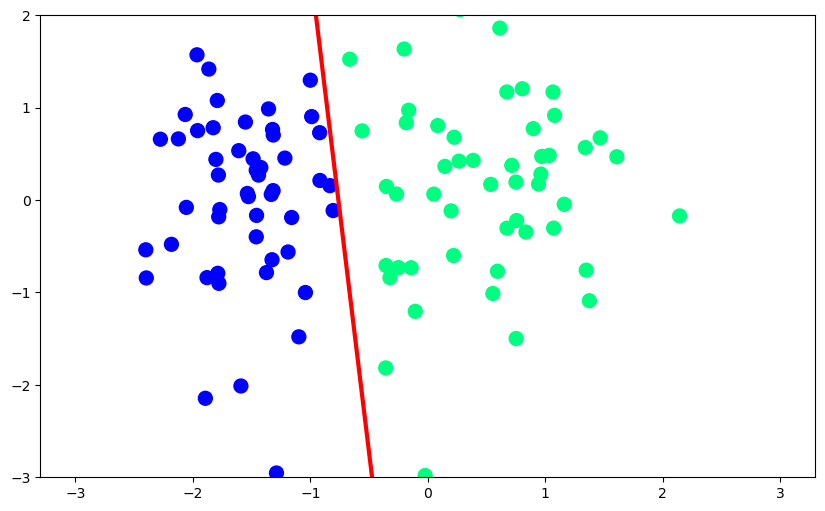

In [201]:

plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [202]:

from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

LogisticRegression()

In [203]:
m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 = -(lor.intercept_/lor.coef_[0][1])

In [204]:

x_input1 = np.linspace(-3,3,100)
y_input1 = m1*x_input1 + b1

In [205]:
y_pred1 = lor.predict(X)

In [206]:
logistic_acc = accuracy_score(y,y_pred1)

In [207]:
logistic_acc

0.99

(-3.0, 2.0)

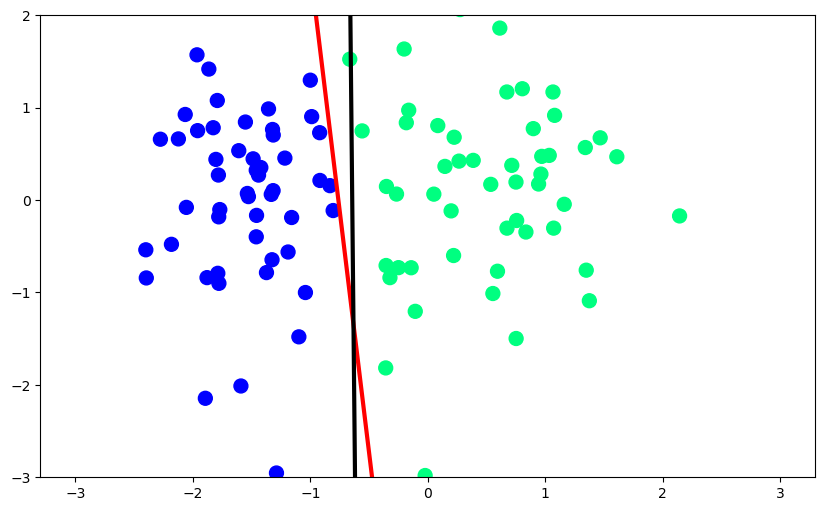

In [208]:

plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3, label="Cuatome Perceptron ")
plt.plot(x_input1,y_input1,color='black',linewidth=3,  label="Logistic Regression")
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [209]:
from sklearn.linear_model import Perceptron

In [210]:
p = Perceptron()

In [211]:
p.fit(X, y)

Perceptron()

In [212]:
y_pred2 = p.predict(X)
perceptron_acc = accuracy_score(y, y_pred2)
perceptron_acc

1.0

In [213]:
# x_input2 = np.linspace(-3,3,100)
# y_input2 = m*x_input + b
p.coef_[0][1]

np.float64(0.1886079879068575)

In [214]:
m2 = -( p.coef_[0][0] / p.coef_[0][1])
b2 = -( p.intercept_ / p.coef_[0][1] )

In [215]:
x_input2 = np.linspace(-3,3,100)
y_input2 = m2*x_input + b2


(-3.0, 2.0)

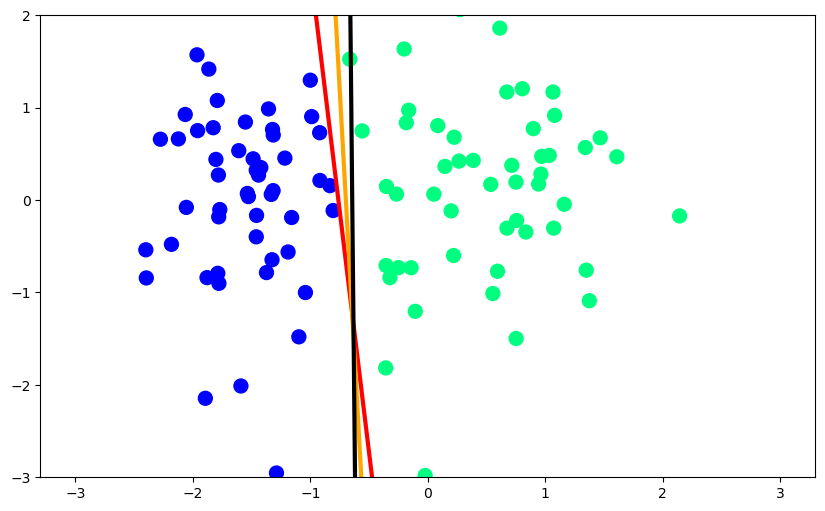

In [216]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3,label="Custom Perceptron") # our model 
plt.plot(x_input2,y_input2,color='orange',linewidth=3,label="Sklearn  Perceptron") # Perceptron 
plt.plot(x_input1,y_input1,color='black',linewidth=3,  label="Logistic Regression") # Logistic regression 

plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [217]:
print(f"Custom Perceptron Accuracy: {custom_acc:.2f}")
print(f"Sklearn Perceptron Accuracy: {perceptron_acc:.2f}")
print(f"Logistic Regression Accuracy: {logistic_acc:.2f}")

Custom Perceptron Accuracy: 1.00
Sklearn Perceptron Accuracy: 1.00
Logistic Regression Accuracy: 0.99


# Logistic reegression internally uses regularization 